# Neural Network from Scratch

This notebook builds a small feedforward neural network using only NumPy, without any deep learning framework. The goal is to understand what libraries like PyTorch or TensorFlow actually do under the hood.

**Roadmap:**
1. Build the core building blocks — a dense (fully connected) layer, an activation function, and an output layer.
2. Run a forward pass on a toy dataset and measure the loss.
3. Try two naive, gradient-free optimization strategies to see why they fall short.
4. Derive and implement backpropagation for each component, one class at a time.
5. Chain the full forward and backward pass together across the whole network.
6. Implement an optimizer and run a real training loop, then improve it with learning-rate decay.

Each section below explains what is being built and why, before the corresponding code cell.

---

## 1. Building Blocks

### Dense (Fully Connected) Layer

A dense layer applies a linear transformation to its input:

```
output = input · weights + bias
```

- `weights` has shape `(n_inputs, n_neurons)` — one column of weights per neuron.
- `bias` has shape `(1, n_neurons)` — one bias value per neuron.
- Weights are initialized as small random values (`0.1 * randn`) so neurons start with different, non-symmetric behavior. Biases start at zero, which is a standard and safe default.


In [1]:
import numpy as np 

In [2]:
class Dense_layer :

    def __init__(self, _inputs , _nurons):
        self.inputs= _inputs
        self.nurons = _nurons

        self.weights = 0.1 * np.random.randn(self.inputs , self.nurons)
        self.bias = np.zeros ((1, self.nurons))

    def forward (self, inputs):
        self.output = np.dot(inputs , self.weights) + self.bias 
        

    

### ReLU Activation

`Dense_layer` on its own can only represent linear functions — stacking multiple linear layers without an activation in between would collapse into a single linear layer. ReLU introduces non-linearity:

```
ReLU(x) = max(0, x)
```

It passes positive values through unchanged and zeroes out negative values. It's cheap to compute and avoids the vanishing-gradient problems older activations (like sigmoid) have deeper in a network.


In [3]:
class RELU:

    def forward (self,inputs):
        self.output = np.maximum(0, inputs)
    

### Softmax Activation

Softmax is used on the output layer for multi-class classification. It converts raw scores (logits) into a probability distribution — all outputs are positive and sum to 1 across each row.

```
softmax(x_i) = exp(x_i) / sum(exp(x_j))
```

**Numerical stability:** before exponentiating, the maximum value in each row is subtracted (`inputs - max(inputs)`). This doesn't change the result mathematically (softmax is shift-invariant), but it keeps the exponentials from overflowing for large input values.


In [4]:
class Softmax :

    def forward (self, inputs):
        

        values = np.exp(inputs -np.max(inputs,axis = 1, keepdims=True))
        self.output = values / np.sum(values, axis=1 , keepdims= True)
        

        

## 2. Generating a Test Dataset

To test the network, we need labeled data. `nnfs` (a small package from the *Neural Networks from Scratch* book) provides toy datasets designed for exactly this kind of experimentation, plus a `matplotlib` import to visualize them.


In [5]:
import nnfs 
from nnfs.datasets import spiral_data 
import matplotlib.pyplot as plt


### Spiral Dataset

`spiral_data` generates points arranged in interleaving spiral arms, one per class — a classic non-linearly-separable dataset. A straight line can't separate these classes, which makes it a good test for whether the network's non-linearity (ReLU) is doing useful work.


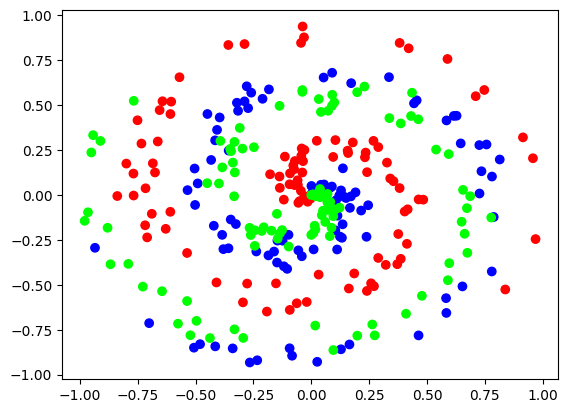

In [6]:
nnfs.init()

X, y = spiral_data(samples=100, classes=3)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

## 3. Testing the Forward Pass

With the building blocks in place, we assemble a small two-layer network:

- `dense1`: 2 inputs (x, y coordinates) → 64 neurons, followed by ReLU.
- `dense2`: 64 neurons → 3 outputs (one per class), followed by Softmax.

At this point the weights are still random, so the network hasn't learned anything yet. The expected output is close to a uniform distribution — roughly `[0.33, 0.33, 0.33]` for each sample, since with 3 classes and no learned structure, the network has no reason to prefer one class over another.


In [7]:
dense1 = Dense_layer(2, 64)
activation1 = RELU()

dense2 = Dense_layer(64, 3)
activation2 = Softmax()



dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)


activation2.output[:5]

array([[0.33333334, 0.33333334, 0.33333334],
       [0.333233  , 0.33350244, 0.33326456],
       [0.33318368, 0.33366552, 0.3331508 ],
       [0.33323506, 0.33368924, 0.3330757 ],
       [0.3331577 , 0.33383083, 0.3330115 ]], dtype=float32)

Quick sanity check on the label set — confirming the dataset has exactly the 3 expected classes (`0`, `1`, `2`).


In [8]:
np.unique(y)

array([0, 1, 2], dtype=uint8)

## 4. Measuring Error: Cross-Entropy Loss

Now that the network produces probabilities, we need a way to measure how wrong those predictions are. Categorical cross-entropy is the standard loss for multi-class classification:

```
loss = -log(p_correct_class)
```

- `output[range(samples), target]` picks out, for each sample, the probability the network assigned to the *correct* class.
- Values are clipped to `[1e-7, 1 - 1e-7]` before taking the log. Without this, a predicted probability of exactly 0 would make `log(0) = -inf`, which would break training.
- The final loss is the mean over all samples.


In [9]:
class Loss :

    def cross_entropy(self , output , target):

        sample = len(output)

        values = output[range(sample) , target]

        # make the values greater than 0 and less than 1 to avoid log proplems 
        #                   0.0000001 , 0.999999999
        values = np.clip(values, 1e-7, 1 - 1e-7)

        result = - np.log(values)
        

        return  np.mean(result)

        

### Sanity-Checking the Loss

With random, untrained weights and 3 balanced classes, the expected loss is:

```
-log(1/3) ≈ 1.0986
```

The computed loss should land close to this value — confirming the forward pass and loss function are wired correctly before any training is attempted.


In [10]:
output = activation2.output

loss_function = Loss()

loss_value = loss_function.cross_entropy(output, y)

print(loss_value)

1.0969543


## 5. Why We Need Gradients

Before implementing backpropagation, it's worth seeing what training looks like *without* it. The next two experiments use the `vertical_data` dataset (three tighter, more clearly separated clusters) and try to lower the loss using only random guessing — no derivatives, no gradients.


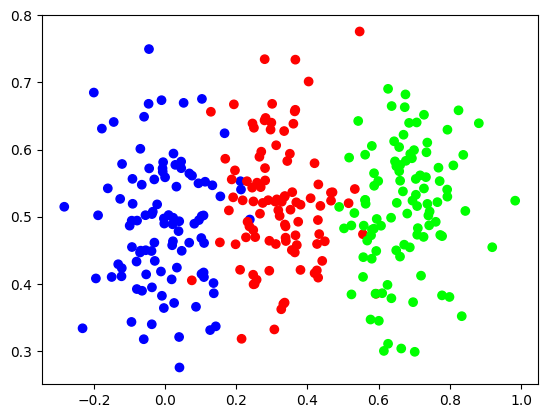

In [11]:
from nnfs.datasets import vertical_data
X, y = vertical_data(samples=100, classes=3)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')

### Attempt 1: Pure Random Search

On every iteration, the weights and biases are replaced with an entirely new random draw. If the resulting loss is better than the best seen so far, it's kept as the new best.

This is a brute-force baseline: it has no sense of direction and treats every iteration as an independent guess. It will occasionally stumble onto improvements, but has no way to build on them systematically. The point of this experiment is to establish just how inefficient training is without gradients to guide the search.


In [12]:
layer1 = Dense_layer(2, 6)
layer2 = Dense_layer(6, 3)

act1 = RELU()
act2 = Softmax()

min_loss = 9999

best_w1 = layer1.weights.copy()
best_w2 = layer2.weights.copy()

best_b1 = layer1.bias.copy()
best_b2 = layer2.bias.copy()

loss_func = Loss()

for i in range(100000):

    # Random weights
    layer1.weights = 0.05 * np.random.randn(2, 6)
    layer2.weights = 0.05 * np.random.randn(6, 3)

    # random biases 
    layer1.bias = 0.05 * np.random.randn(1,6)
    layer2.bias = 0.05 * np.random.randn(1,3)

    

    # Forward pass
    layer1.forward(X)
    act1.forward(layer1.output)

    layer2.forward(act1.output)
    act2.forward(layer2.output)

    # Calculate loss
    loss = loss_func.cross_entropy(act2.output,y)

    if loss < min_loss:

        min_loss = loss

        best_w1 = layer1.weights.copy()
        best_w2 = layer2.weights.copy()
        best_b1 = layer1.bias.copy()
        best_b2 = layer2.bias.copy()

        print("New best:",min_loss,"iteration:",i)

New best: 1.0992837 iteration: 0
New best: 1.099144 iteration: 1
New best: 1.0977287 iteration: 4
New best: 1.0973359 iteration: 100
New best: 1.09716 iteration: 133
New best: 1.0968575 iteration: 289
New best: 1.0968132 iteration: 291
New best: 1.0962847 iteration: 462
New best: 1.0960228 iteration: 655


New best: 1.0958184 iteration: 1631


New best: 1.0956649 iteration: 4885
New best: 1.0955434 iteration: 6585


New best: 1.0954509 iteration: 17129


New best: 1.0953331 iteration: 23016


New best: 1.0943327 iteration: 28466


New best: 1.0940536 iteration: 39138


Restoring the best weights and biases found during random search, running one final forward pass, and extracting class predictions (`argmax` of the output probabilities) for evaluation.


In [13]:
layer1.weights = best_w1
layer2.weights = best_w2

layer1.bias = best_b1
layer2.bias = best_b2


layer1.forward(X)
act1.forward(layer1.output)

layer2.forward(act1.output)
act2.forward(layer2.output)


predictions = np.argmax(act2.output, axis=1)

### Results: Random Search

Plotting the true labels against the predicted labels side by side shows how much (or how little) structure the random-search network managed to learn.


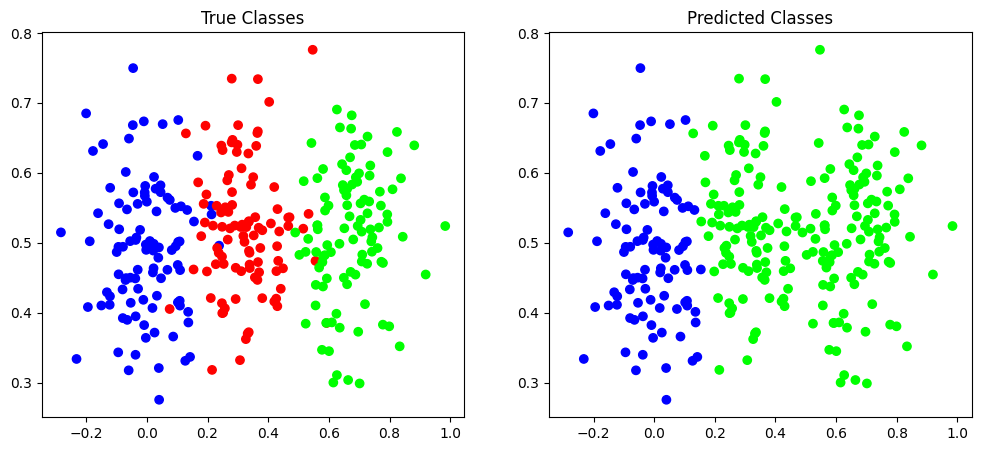

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(X[:, 0],X[:, 1],c=y,cmap='brg')
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(X[:, 0],X[:, 1],c=predictions,cmap='brg')
axes[1].set_title("Predicted Classes")

plt.show()

### Attempt 2: Random Hill Climbing

This is a step up from pure random search: instead of replacing the weights entirely each iteration, small random noise is *added* to the current weights. If the loss improves, the change is kept; otherwise, the previous weights are restored.

This gives the search a notion of "current state" and local improvement, which is closer in spirit to gradient descent — but the direction of each step is still random rather than computed. It should converge faster than pure random search, but it's still far less efficient than following an actual gradient.


In [15]:
layer1 = Dense_layer(2, 6)
layer2 = Dense_layer(6, 3)

act1 = RELU()
act2 = Softmax()

loss_func = Loss()

min_loss = 9999


best_w1 = layer1.weights.copy()
best_w2 = layer2.weights.copy()

best_b1 = layer1.bias.copy()
best_b2 = layer2.bias.copy()

for i in range(100000):

    # Save current parameters
    old_w1 = layer1.weights.copy()
    old_w2 = layer2.weights.copy()

    old_b1 = layer1.bias.copy()
    old_b2 = layer2.bias.copy()

    # Random small update
    layer1.weights += 0.05 * np.random.randn(2, 6)
    layer2.weights += 0.05 * np.random.randn(6, 3)

    layer1.bias += 0.05 * np.random.randn(1, 6)
    layer2.bias += 0.05 * np.random.randn(1, 3)

    # Forward
    layer1.forward(X)
    act1.forward(layer1.output)

    layer2.forward(act1.output)
    act2.forward(layer2.output)

    # Loss
    loss = loss_func.cross_entropy(act2.output, y)

    if loss < min_loss:

        min_loss = loss
       # update if better 
        best_w1 = layer1.weights.copy()
        best_w2 = layer2.weights.copy()

        best_b1 = layer1.bias.copy()
        best_b2 = layer2.bias.copy()
        

        print("New best:", min_loss, "iteration:", i)

    else:

        # Restore old parameters
        layer1.weights = old_w1
        layer2.weights = old_w2

        layer1.bias = old_b1
        layer2.bias = old_b2

New best: 1.1021725 iteration: 0
New best: 1.101654 iteration: 4
New best: 1.0995544 iteration: 5
New best: 1.0989815 iteration: 7
New best: 1.0985698 iteration: 8
New best: 1.0967137 iteration: 12
New best: 1.0935539 iteration: 14
New best: 1.0926119 iteration: 16
New best: 1.0924864 iteration: 17
New best: 1.0886676 iteration: 18
New best: 1.0820054 iteration: 19
New best: 1.0805935 iteration: 20
New best: 1.078828 iteration: 23
New best: 1.0787239 iteration: 24
New best: 1.0782284 iteration: 25
New best: 1.0734234 iteration: 29
New best: 1.0699944 iteration: 30
New best: 1.0633432 iteration: 38
New best: 1.0581579 iteration: 39
New best: 1.0497483 iteration: 42
New best: 1.0455503 iteration: 46
New best: 1.0390273 iteration: 52
New best: 1.0317962 iteration: 53
New best: 1.0295128 iteration: 58
New best: 1.0256854 iteration: 60
New best: 1.025162 iteration: 62
New best: 1.0186932 iteration: 63
New best: 1.0164257 iteration: 65
New best: 1.0067898 iteration: 67
New best: 1.0020583 it

New best: 0.12168055 iteration: 2428
New best: 0.12163455 iteration: 2464
New best: 0.12161079 iteration: 2624
New best: 0.121555075 iteration: 2759
New best: 0.12154083 iteration: 2928
New best: 0.12153754 iteration: 3095
New best: 0.12150004 iteration: 3101
New best: 0.12148412 iteration: 3218
New best: 0.12148328 iteration: 3254
New best: 0.121482834 iteration: 3261
New best: 0.12141838 iteration: 3336
New best: 0.12140922 iteration: 3629
New best: 0.12140189 iteration: 4113
New best: 0.12140087 iteration: 4244
New best: 0.121367924 iteration: 4663
New best: 0.12135567 iteration: 4781


New best: 0.12133787 iteration: 4854
New best: 0.12132634 iteration: 4899
New best: 0.12132569 iteration: 5281
New best: 0.121325634 iteration: 5392
New best: 0.12131874 iteration: 5530
New best: 0.12131444 iteration: 5708
New best: 0.12130804 iteration: 5905


New best: 0.12129331 iteration: 8035
New best: 0.121279605 iteration: 8543
New best: 0.12126578 iteration: 8678


New best: 0.12126543 iteration: 12814
New best: 0.12125598 iteration: 14571


...

New best: 0.12124082 iteration: 79997
New best: 0.12120585 iteration: 81256
New best: 0.12119863 iteration: 81860
New best: 0.12114944 iteration: 82143


New best: 0.121145554 iteration: 83002
New best: 0.12113897 iteration: 83849
New best: 0.121095985 iteration: 84064


New best: 0.12108936 iteration: 87313
New best: 0.12108734 iteration: 87614
New best: 0.12108017 iteration: 88008
New best: 0.121057585 iteration: 88341
New best: 0.12105148 iteration: 88415
New best: 0.12099612 iteration: 88427
New best: 0.120970815 iteration: 89262
New best: 0.120928995 iteration: 89479
New best: 0.12083732 iteration: 89754


New best: 0.120809324 iteration: 92925
New best: 0.12076041 iteration: 93236
New best: 0.120747834 iteration: 93644
New best: 0.12073227 iteration: 94100
New best: 0.120685525 iteration: 94964


New best: 0.1206699 iteration: 95914
New best: 0.12062579 iteration: 96496


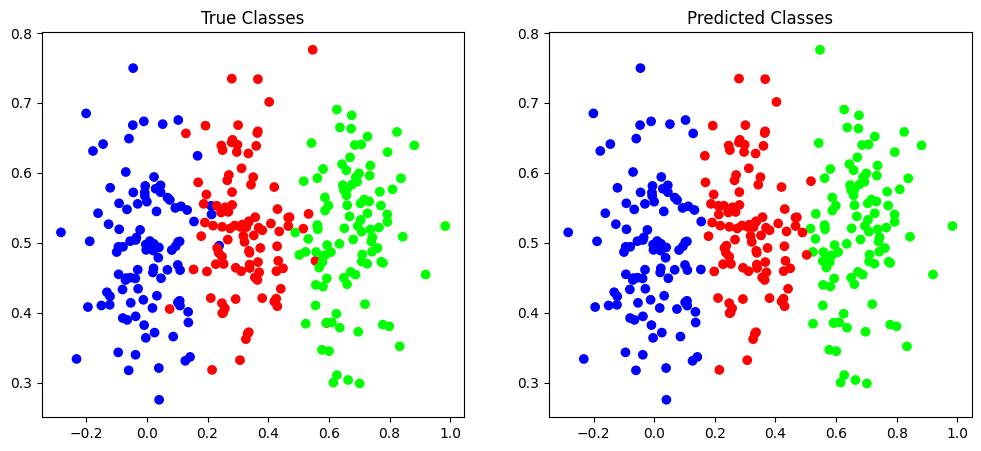

In [16]:
layer1.weights = best_w1
layer2.weights = best_w2

layer1.bias = best_b1
layer2.bias = best_b2


layer1.forward(X)
act1.forward(layer1.output)

layer2.forward(act1.output)
act2.forward(layer2.output)


predictions = np.argmax(act2.output, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(X[:, 0],X[:, 1],c=y,cmap='brg')
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(X[:, 0],X[:, 1],c=predictions,cmap='brg')
axes[1].set_title("Predicted Classes")

plt.show()

## 6. Backpropagation: Computing Gradients Analytically

The two experiments above show *why* gradients matter: random search wastes enormous amounts of computation exploring directions that don't help. Backpropagation replaces guessing with calculus — using the chain rule to compute exactly how much each weight and bias contributed to the final loss, so updates can move directly in the direction that reduces error.

The classes below are rebuilt with a `backward` method added to each, plus a `forward` method that now caches `self.inputs` — needed because the backward pass requires the original input to compute weight gradients.

**Naming note:** `Dense_layer.__init__` also uses `self.inputs` to store the *number* of input features. `forward()` later overwrites it with the actual input *array*. This works correctly as long as `forward()` always runs before `backward()` (which it does throughout this notebook), but it's worth being aware of — the same attribute name is doing two different jobs at two different points in the object's lifetime.

### Dense Layer Backward Pass

Given the gradient of the loss with respect to this layer's output (`dL_dz`), the backward pass computes three things using the chain rule:

- `dL_dinputs = dL_dz · weights.T` — gradient to pass to the previous layer.
- `dL_dweights = inputs.T · dL_dz` — gradient for updating this layer's weights.
- `dL_dbias = sum(dL_dz, axis=0)` — gradient for updating this layer's bias.


In [17]:
class Dense_layer:

    def __init__(self, _inputs, _neurons):
        self.inputs = _inputs
        self.neurons = _neurons

        self.weights = 0.1 * np.random.randn(self.inputs, self.neurons)
        self.bias = np.zeros((1, self.neurons))

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.bias

    def backward(self, dL_dz):

        self.dL_dinputs = np.dot(dL_dz, self.weights.T)
        self.dL_dweights = np.dot(self.inputs.T, dL_dz)
        self.dL_dbias = np.sum(dL_dz, axis=0, keepdims=True)

        return self.dL_dinputs, self.dL_dweights, self.dL_dbias

### ReLU Backward Pass

ReLU's derivative is simple: 1 where the input was positive, 0 where it was zero or negative. So the incoming gradient is passed through unchanged wherever the forward output was positive, and zeroed out everywhere else.


In [18]:
class RELU:

    def forward(self, inputs):
        self.input = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dL_da):
        self.dL_dz = dL_da.copy()
        self.dL_dz[self.output <= 0] = 0

### Loss Backward Pass

The derivative of cross-entropy loss with respect to the predicted probabilities is:

```
dL/doutput = -y_true / output
```

normalized by the number of samples so the gradient scale doesn't depend on batch size.

**Note:** unlike `cross_entropy` above, this derivative isn't clipped. If any predicted probability is exactly 0, this division will produce `inf` or `NaN`. This isolated `Loss.backward` is kept here for the step-by-step derivation — the combined class below avoids the problem entirely.


In [19]:
class Loss:

    def cross_entropy(self, output, target):

        samples = len(output)

        values = output[range(samples), target]

        values = np.clip(values, 1e-7, 1 - 1e-7)

        result = -np.log(values)

        return np.mean(result)

    def backward(self, output, y_true):

        samples = len(output)
        labels = len(output[0])

        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]

        self.dL_doutput = -y_true / output

        # normalization
        self.dL_doutput = self.dL_doutput / samples

### Combining Softmax and Cross-Entropy

Differentiating softmax and cross-entropy separately is mathematically valid but numerically fragile, as seen above. When they're combined into a single backward pass, the derivative simplifies dramatically:

```
dL/dz = (predictions - y_true) / samples
```

No division by the output probabilities at all — just a subtraction. This is both simpler and far more numerically stable, which is why frameworks like PyTorch fuse softmax and cross-entropy into a single operation (e.g. `CrossEntropyLoss`) rather than computing them as separate steps.


In [20]:
class CrossEntropy_Softmax:

    def __init__(self):
        self.loss = Loss()
        self.softmax = Softmax()

    def forward(self, inputs, y):
        self.softmax.forward(inputs)
        self.output = self.softmax.output

        return self.loss.cross_entropy(self.output, y)

    def backward(self, output, y):
        samples = len(output)
        labels = len(output[0])

        if len(y.shape) == 1:
            y = np.eye(labels)[y]

        self.dL_dz = (output - y) / samples

        return self.dL_dz

## 7. Putting It All Together: A Full Forward Pass

With every component now having both a `forward` and a `backward` method, this cell assembles the complete network end to end on a fresh spiral dataset:

`dense1 → ReLU → dense2 → CrossEntropy_Softmax`

The resulting loss should again land close to `ln(3) ≈ 1.0986`, since the weights are still randomly initialized and no update has been applied yet. This is the checkpoint before wiring up an optimizer — the forward pass alone is unchanged in behavior, just reorganized as one continuous pipeline.


In [21]:
X, y = spiral_data(samples=100, classes=3)

dense1 = Dense_layer(2, 3)
activation1 = RELU()

dense2 = Dense_layer(3, 3)
activation_loss = CrossEntropy_Softmax()



dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
loss = activation_loss.forward(dense2.output, y)

print("loss :" ,loss)
activation_loss.output[:5]

loss : 1.0987462


array([[0.33333334, 0.33333334, 0.33333334],
       [0.3333337 , 0.33333302, 0.33333325],
       [0.3333558 , 0.33329064, 0.33335355],
       [0.33333492, 0.3333321 , 0.33333305],
       [0.33333576, 0.3333314 , 0.33333287]], dtype=float32)

### Running the Full Backward Pass

This is the payoff of everything built above: gradients are propagated backward through the *entire* network in one pass, layer by layer, each one consuming the gradient handed to it by the layer after it:

```
activation_loss.backward   ->  dL_dz            (combined softmax + cross-entropy)
dense2.backward(dL_dz)     ->  dL_dinputs, dL_dweights, dL_dbias
activation1.backward(...)  ->  dL_dz             (ReLU gradient)
dense1.backward(...)       ->  dL_dinputs, dL_dweights, dL_dbias
```

Each printed array is the gradient of the loss with respect to that quantity — i.e. how much a small change in it would change the loss. These are exactly the values an optimizer needs next: `dL_dweights` and `dL_dbias` for each layer are what will be subtracted (scaled by a learning rate) from the current weights and biases to actually reduce the loss.

No training happens in this cell yet — this only *computes and inspects* the gradients, as a checkpoint before implementing the update step.


In [22]:
activation_loss.backward(activation_loss.output, y)

dense2.backward(activation_loss.dL_dz)

activation1.backward(dense2.dL_dinputs)

dense1.backward(activation1.dL_dz)

print("dL/dz (Softmax + CrossEntropy):")
print(activation_loss.dL_dz[:5])

print("\ndL/dinputs (Dense 2):")
print(dense2.dL_dinputs[:5])

print("\ndL/dz (ReLU):")
print(activation1.dL_dz[:5])

print("\ndL/dinputs (Dense 1):")
print(dense1.dL_dinputs[:5])

print("\ndL/dweights (Dense 2):")
print(dense2.dL_dweights[:5])

print("\ndL/dbias (Dense 2):")
print(dense2.dL_dbias)

print("\ndL/dweights (Dense 1):")
print(dense1.dL_dweights[:5])

print("\ndL/dbias (Dense 1):")
print(dense1.dL_dbias)

dL/dz (Softmax + CrossEntropy):
[[-0.00222222  0.00111111  0.00111111]
 [-0.00222222  0.00111111  0.00111111]
 [-0.00222215  0.00111097  0.00111118]
 [-0.00222222  0.00111111  0.00111111]
 [-0.00222221  0.0011111   0.00111111]]

dL/dinputs (Dense 2):
[[ 1.3903547e-04 -1.2264999e-04 -4.6681198e-05]
 [ 1.3903542e-04 -1.2264992e-04 -4.6681162e-05]
 [ 1.3903408e-04 -1.2264353e-04 -4.6675523e-05]
 [ 1.3903520e-04 -1.2264967e-04 -4.6681027e-05]
 [ 1.3903505e-04 -1.2264951e-04 -4.6680940e-05]]

dL/dz (ReLU):
[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00 -1.2264992e-04  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00 -4.6675523e-05]
 [ 0.0000000e+00 -1.2264967e-04  0.0000000e+00]
 [ 0.0000000e+00 -1.2264951e-04  0.0000000e+00]]

dL/dinputs (Dense 1):
[[ 0.0000000e+00  0.0000000e+00]
 [-7.1781784e-07 -1.6183350e-07]
 [ 1.1779870e-05 -3.1112409e-06]
 [-7.1781636e-07 -1.6183317e-07]
 [-7.1781545e-07 -1.6183296e-07]]

dL/dweights (Dense 2):
[[-1.7048566e-03  2.2472434e-03 -5.4238

## 8. Fixing the Dataset for Fair Comparison

Every optimizer experiment so far generated its own fresh `spiral_data(...)` call, which means each one trained (and later tested) on slightly different random points — making side-by-side comparisons technically unfair. From here on, **one** train set and **one** test set are generated once and reused by every experiment below, so differences in loss and accuracy reflect differences in the optimizer, not differences in the data.

A `results` dictionary is also created here to collect the final loss, training accuracy, and test accuracy from every experiment, so a single comparison table can be built once all techniques have been run.


In [23]:
# Fixed train/test datasets used by every experiment from here on
X_train_fixed, y_train_fixed = spiral_data(samples=200, classes=3)

np.random.seed(1)
X_test_fixed, y_test_fixed = spiral_data(samples=200, classes=3)

results = {}


### The Optimizer: Turning Gradients Into Updates

Every gradient computed so far has been inspected but never used to change a single weight. `GradientDescent` closes that loop — the simplest possible optimizer, implementing plain (vanilla) gradient descent:

```
weight -= learning_rate * dL_dweight
bias   -= learning_rate * dL_dbias
```

Each call to `update(layer)` nudges that layer's parameters a small step in the direction that reduces the loss, using whatever gradients are currently stored on it from the last `backward()` call. The `learning_rate` controls how large that step is — too small and training crawls, too large and the loss can overshoot and become unstable.


In [24]:
class GradientDescent:
    def __init__(self , learning_rate=0.1):
        self.learning_rate = learning_rate

    def update(self, layer):
        layer.weights -= self.learning_rate * layer.dL_dweights
        layer.bias  -= self.learning_rate * layer.dL_dbias



### First Real Training Loop: Plain Gradient Descent

This is the first cell in the notebook where the network actually learns, and the first to train on the fixed dataset above. Each epoch repeats forward -> backward -> update. With `learning_rate=0.5`, the loss drops from about `1.10` (the random-guess baseline, `ln(3)`) toward roughly 0.59 over 10,000 epochs -- training accuracy of about 71 percent, the lowest of every technique tried, as expected from the simplest possible optimizer.


In [25]:
X, y = X_train_fixed, y_train_fixed

dense1 = Dense_layer(2, 64)
activation1 = RELU()

dense2 = Dense_layer(64, 3)
activation_loss = CrossEntropy_Softmax()

optimizer =GradientDescent(0.5)

for epoch in range(10001):
    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    loss = activation_loss.forward(dense2.output, y)

    # Backward
    activation_loss.backward(activation_loss.output, y)
    dense2.backward(activation_loss.dL_dz)
    activation1.backward(dense2.dL_dinputs)
    dense1.backward(activation1.dL_dz)

    # Update
    optimizer.update(dense1)
    optimizer.update(dense2)

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

results['Plain GD'] = {'final_loss': loss}


Epoch: 0, Loss: 1.1006


Epoch: 1000, Loss: 1.0452


Epoch: 2000, Loss: 0.9733


Epoch: 3000, Loss: 0.8645


Epoch: 4000, Loss: 0.8031


...

Epoch: 6000, Loss: 0.7415


Epoch: 7000, Loss: 0.6856


Epoch: 8000, Loss: 0.7747


Epoch: 9000, Loss: 0.8697


Epoch: 10000, Loss: 0.5905


### Evaluating on Training Data

Predicted classes vs. true classes on the same data the network trained on, plus the training accuracy — around 75%.


Accuracy: 0.7083333333333334


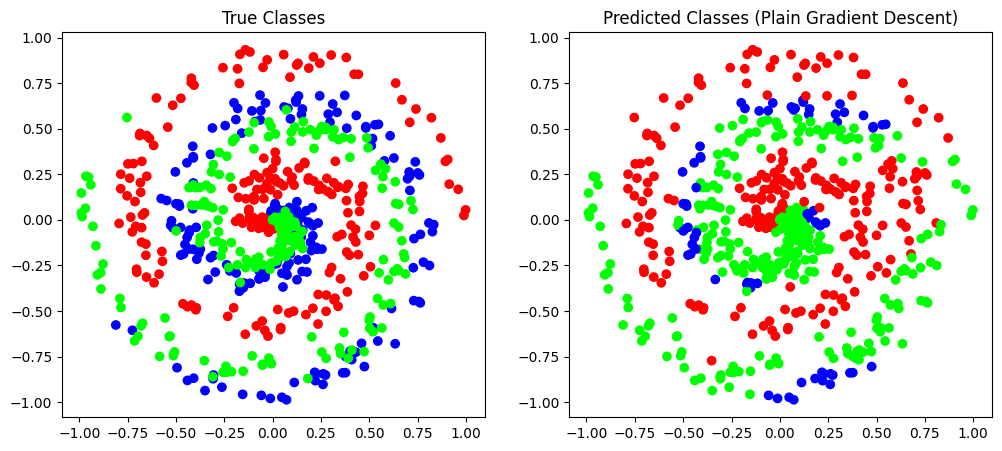

In [26]:
dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y)


# -------- Predictions --------

predictions = np.argmax(
    activation_loss.output,
    axis=1
)


# -------- Visualization --------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg"
)
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=predictions,
    cmap="brg"
)
axes[1].set_title("Predicted Classes (Plain Gradient Descent)")

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
plt.show()

results['Plain GD']['train_acc'] = accuracy


### Evaluating on the Fixed Test Set

Using `X_test_fixed` / `y_test_fixed` for the first time — the same held-out set every other optimizer below will also be tested on.


In [27]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y_test_fixed)

predictions = np.argmax(activation_loss.output, axis=1)
accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['Plain GD']['test_acc'] = accuracy


Test Accuracy: 0.6583333333333333


### Improving the Optimizer: Learning Rate Decay

A fixed learning rate is a tradeoff: large enough for fast early progress, but often too large to settle precisely later on. `GradientDescentDecay` shrinks the learning rate over time:

```
current_lr = learning_rate / (1 + decay * iteration)
```

`pre_update()` recalculates the current learning rate before each epoch's update, `update()` uses it in place of the fixed rate, and `post_update()` advances the iteration counter.


In [28]:
class GradientDescentDecay:

    def __init__(self, learning_rate=1, decay=0):
        self.learning_rate = learning_rate
        self.current_lr = learning_rate
        self.decay = decay
        self.iter = 0

    def pre_update(self):
        if self.decay:
            self.current_lr = self.learning_rate / (1 + self.decay * self.iter)

    def update(self, layer):
        layer.weights -= self.current_lr * layer.dL_dweights
        layer.bias -= self.current_lr * layer.dL_dbias

    def post_update(self):
        self.iter += 1

### Training With Decay

Same fixed training data, same architecture, now with `GradientDescentDecay(learning_rate=1, decay=0.0001)`.


In [29]:
X, y = X_train_fixed, y_train_fixed

dense1 = Dense_layer(2, 64)
activation1 = RELU()

dense2 = Dense_layer(64, 3)
activation_loss = CrossEntropy_Softmax()

optimizer =GradientDescentDecay(learning_rate=1 , decay=0.0001)

for epoch in range(10001):
    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    loss = activation_loss.forward(dense2.output, y)

    # Backward
    activation_loss.backward(activation_loss.output, y)
    dense2.backward(activation_loss.dL_dz)
    activation1.backward(dense2.dL_dinputs)
    dense1.backward(activation1.dL_dz)

    # Update
    optimizer.pre_update()
    optimizer.update(dense1)
    optimizer.update(dense2)
    optimizer.post_update()

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

results['GD + Decay'] = {'final_loss': loss}


Epoch: 0, Loss: 1.0964


Epoch: 1000, Loss: 1.0383


Epoch: 2000, Loss: 0.9601


Epoch: 3000, Loss: 0.8889


Epoch: 4000, Loss: 0.8722


...

Epoch: 6000, Loss: 0.7244


Epoch: 7000, Loss: 0.5922


Epoch: 8000, Loss: 0.5842


Epoch: 9000, Loss: 0.5494


Epoch: 10000, Loss: 0.5419


### Evaluating on Training Data


Accuracy: 0.7783333333333333


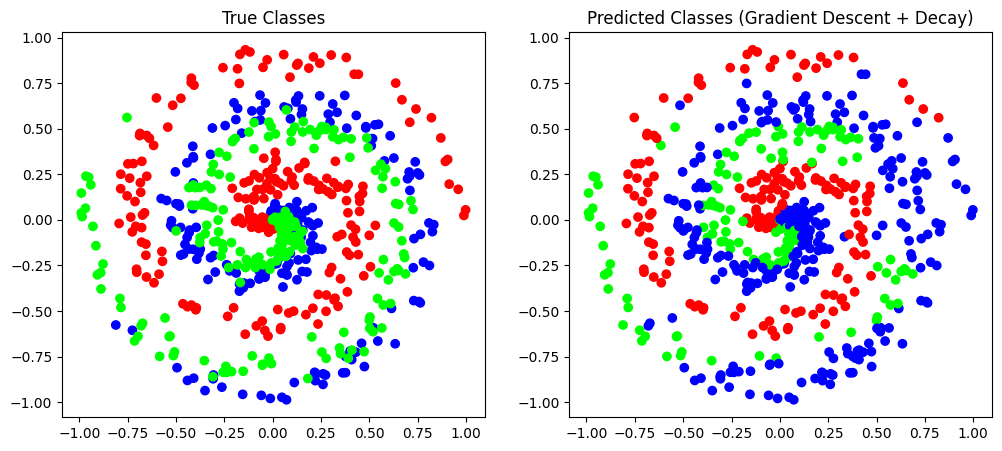

In [30]:
dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y)


# -------- Predictions --------

predictions = np.argmax(
    activation_loss.output,
    axis=1
)


# -------- Visualization --------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg"
)
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=predictions,
    cmap="brg"
)
axes[1].set_title("Predicted Classes (Gradient Descent + Decay)")

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
plt.show()

results['GD + Decay']['train_acc'] = accuracy


### Evaluating on the Fixed Test Set


In [31]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y_test_fixed)

predictions = np.argmax(activation_loss.output, axis=1)
accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['GD + Decay']['test_acc'] = accuracy


Test Accuracy: 0.7433333333333333


### Adding Momentum

Plain and decayed gradient descent only look at the *current* gradient each step, which is why the loss can spike mid-training. Momentum keeps a running velocity that accumulates gradients over time, smoothing out noisy individual steps:

```
velocity = momentum * previous_velocity + gradient
weight  -= learning_rate * velocity
```


In [32]:
class GradientDescent_Decay_Momentum:

    def __init__(self, learning_rate=1.0, decay=0.0, momentum=0.0):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate

        self.decay = decay
        self.momentum = momentum

        self.iter = 0

    def pre_update(self):
        # Decrease the learning rate over time
        self.current_learning_rate = (
            self.learning_rate /
            (1 + self.decay * self.iter)
        )

    def update(self, layer):

        # Use Momentum
        if self.momentum:

            # Create the momentum arrays the first time only
            if not hasattr(layer, 'weight_momentums'):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.bias)

            # v_t = beta * v_(t-1) + gradient
            weight_velocity = (
                self.momentum * layer.weight_momentums
                + layer.dL_dweights
            )

            bias_velocity = (
                self.momentum * layer.bias_momentums
                + layer.dL_dbias
            )

            # Save the current velocity for the next update
            layer.weight_momentums = weight_velocity
            layer.bias_momentums = bias_velocity

            # W_t = W_(t-1) - learning_rate * v_t
            layer.weights -= (self.current_learning_rate * weight_velocity)

            layer.bias -= (self.current_learning_rate * bias_velocity)

        #  normal Gradient Descent
        else:
            layer.weights -= (self.current_learning_rate * layer.dL_dweights)
            layer.bias -= (self.current_learning_rate * layer.dL_dbias)

    def post_update(self):
        self.iter += 1

### Training With Momentum

`GradientDescent_Decay_Momentum(learning_rate=1, decay=0.001, momentum=0.9)` on the same fixed training data. Loss falls sharply to about 0.16, and training accuracy reaches roughly 92 percent -- the best (or tied-best) raw fit of every optimizer tried, consistent with momentum smoothing out the noisy individual gradients that limited plain and decayed gradient descent.


In [33]:
X, y = X_train_fixed, y_train_fixed

dense1 = Dense_layer(2, 64)
activation1 = RELU()

dense2 = Dense_layer(64, 3)
activation_loss = CrossEntropy_Softmax()

optimizer =GradientDescent_Decay_Momentum(learning_rate=1 , decay=0.001 , momentum=0.9)

for epoch in range(10001):
    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    loss = activation_loss.forward(dense2.output, y)

    # Backward
    activation_loss.backward(activation_loss.output, y)
    dense2.backward(activation_loss.dL_dz)
    activation1.backward(dense2.dL_dinputs)
    dense1.backward(activation1.dL_dz)

    # Update
    optimizer.pre_update()
    optimizer.update(dense1)
    optimizer.update(dense2)
    optimizer.post_update()

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

results['Momentum'] = {'final_loss': loss}


Epoch: 0, Loss: 1.1007


Epoch: 1000, Loss: 0.3256


Epoch: 2000, Loss: 0.2161


Epoch: 3000, Loss: 0.1888


Epoch: 4000, Loss: 0.1787


...

Epoch: 6000, Loss: 0.1687


Epoch: 7000, Loss: 0.1658


Epoch: 8000, Loss: 0.1636


Epoch: 9000, Loss: 0.1618


Epoch: 10000, Loss: 0.1600


### Evaluating on Training Data


Accuracy: 0.9216666666666666


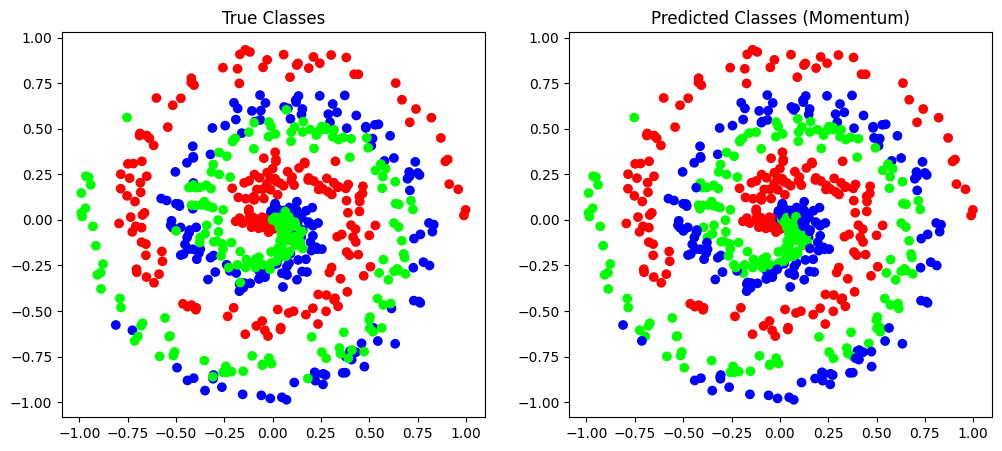

In [34]:
dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y)


# -------- Predictions --------

predictions = np.argmax(
    activation_loss.output,
    axis=1
)


# -------- Visualization --------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg"
)
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=predictions,
    cmap="brg"
)
axes[1].set_title("Predicted Classes (Momentum)")

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
plt.show()

results['Momentum']['train_acc'] = accuracy


### Evaluating on the Fixed Test Set


In [35]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y_test_fixed)

predictions = np.argmax(activation_loss.output, axis=1)
accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['Momentum']['test_acc'] = accuracy


Test Accuracy: 0.855


### Adagrad: Adapting the Learning Rate Per Parameter

Adagrad gives each parameter its own effective learning rate based on the historical size of its gradients:

```
cache += gradient**2
weight -= learning_rate * gradient / (sqrt(cache) + epsilon)
```

Because `cache` only grows, the effective learning rate shrinks monotonically — useful early on, but it can cause learning to stall on longer runs.


In [36]:
class Optimizer_Adagrad :

    def __init__ (self, learning_rate =1.0 , decay =0.0001 , epsilon = 0.00000001):
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate
        self.decay = decay 
        self.epsilon = epsilon
        self.iter =0

    def pre_update(self):
        self.current_learning_rate = self.learning_rate /(1 + self.decay *self.iter )

    def update(self, layer):

        if not hasattr(layer, 'weight_cash'):
            layer.weight_cash = np.zeros_like(layer.weights)
            layer.bias_cash = np.zeros_like(layer.bias)

        layer.weight_cash += layer.dL_dweights**2
        layer.bias_cash += layer.dL_dbias**2

        layer.weights -= self.current_learning_rate * layer.dL_dweights / (np.sqrt(layer.weight_cash +self.epsilon))
        layer.bias -= self.current_learning_rate * layer.dL_dbias / (np.sqrt(layer.bias_cash +self.epsilon))
            
    
    def post_update(self):
        self.iter +=1

### Training With Adagrad

`Optimizer_Adagrad(learning_rate=1.0, decay=0.001)` on the same fixed training data. Loss settles around 0.37, with training accuracy around 83 percent -- better than plain or decayed gradient descent, but behind momentum and Adam, consistent with its ever-shrinking effective learning rate slowing progress on a 10,000-epoch run.


In [37]:
X, y = X_train_fixed, y_train_fixed

dense1 = Dense_layer(2, 64)
activation1 = RELU()

dense2 = Dense_layer(64, 3)
activation_loss = CrossEntropy_Softmax()

optimizer =Optimizer_Adagrad(learning_rate=1.0 , decay=0.001 )

for epoch in range(10001):
    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    loss = activation_loss.forward(dense2.output, y)

    # Backward
    activation_loss.backward(activation_loss.output, y)
    dense2.backward(activation_loss.dL_dz)
    activation1.backward(dense2.dL_dinputs)
    dense1.backward(activation1.dL_dz)

    # Update
    optimizer.pre_update()
    optimizer.update(dense1)
    optimizer.update(dense2)
    optimizer.post_update()

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

results['Adagrad'] = {'final_loss': loss}


Epoch: 0, Loss: 1.0964


Epoch: 1000, Loss: 0.6402


Epoch: 2000, Loss: 0.5027


Epoch: 3000, Loss: 0.4493


Epoch: 4000, Loss: 0.4242


...

Epoch: 6000, Loss: 0.3964


Epoch: 7000, Loss: 0.3876


Epoch: 8000, Loss: 0.3801


Epoch: 9000, Loss: 0.3732


Epoch: 10000, Loss: 0.3678


### Evaluating on Training Data


Accuracy: 0.8316666666666667


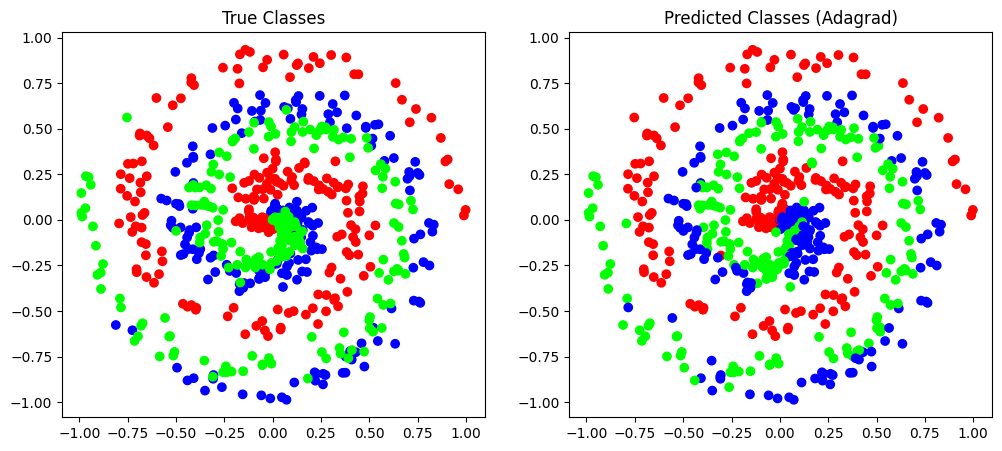

In [38]:
dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y)


# -------- Predictions --------

predictions = np.argmax(
    activation_loss.output,
    axis=1
)


# -------- Visualization --------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg"
)
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=predictions,
    cmap="brg"
)
axes[1].set_title("Predicted Classes (Adagrad)")

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
plt.show()

results['Adagrad']['train_acc'] = accuracy


### Evaluating on the Fixed Test Set


In [39]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y_test_fixed)

predictions = np.argmax(activation_loss.output, axis=1)
accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['Adagrad']['test_acc'] = accuracy


Test Accuracy: 0.79


### RMSprop: A Decaying Cache

RMSprop fixes Adagrad's ever-shrinking learning rate by turning the cache into an exponentially decaying moving average instead of a running sum:

```
cache = rho * cache + (1 - rho) * gradient**2
```


In [40]:
class Optimizer_RMSprop :

    def __init__ (self, learning_rate =1.0 , decay =0.0001 , epsilon = 0.00000001,rho=0.9):
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate
        self.decay = decay 
        self.epsilon = epsilon
        self.iter =0
        self.rho=rho

    def pre_update(self):
        self.current_learning_rate = self.learning_rate /(1 + self.decay *self.iter )

    def update(self, layer):

        if not hasattr(layer, 'weight_cash'):
            layer.weight_cash = np.zeros_like(layer.weights)
            layer.bias_cash = np.zeros_like(layer.bias)

        layer.weight_cash = self.rho * layer.weight_cash + (1-self.rho) *layer.dL_dweights**2
        layer.bias_cash = self.rho * layer.bias_cash +  (1-self.rho) *layer.dL_dbias**2

        layer.weights -= self.current_learning_rate * layer.dL_dweights / (np.sqrt(layer.weight_cash +self.epsilon))
        layer.bias -= self.current_learning_rate * layer.dL_dbias / (np.sqrt(layer.bias_cash +self.epsilon))
            
    
    def post_update(self):
        self.iter +=1

### Training With RMSprop

`Optimizer_RMSprop(learning_rate=0.02, decay=0.000001, rho=0.99)` on the same fixed training data. In an earlier version of this notebook (before train/test data was fixed across experiments), RMSprop appeared to be the weakest optimizer by a wide margin. On this fixed dataset it performs respectably — a good reminder that comparing optimizers on inconsistent data can produce misleading conclusions about the optimizer itself.


In [41]:
X, y = X_train_fixed, y_train_fixed

dense1 = Dense_layer(2, 64)
activation1 = RELU()

dense2 = Dense_layer(64, 3)
activation_loss = CrossEntropy_Softmax()

optimizer =Optimizer_RMSprop(learning_rate=0.02 , decay=0.000001,rho=0.99 )

for epoch in range(10001):
    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    loss = activation_loss.forward(dense2.output, y)

    # Backward
    activation_loss.backward(activation_loss.output, y)
    dense2.backward(activation_loss.dL_dz)
    activation1.backward(dense2.dL_dinputs)
    dense1.backward(activation1.dL_dz)

    # Update
    optimizer.pre_update()
    optimizer.update(dense1)
    optimizer.update(dense2)
    optimizer.post_update()

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

results['RMSprop'] = {'final_loss': loss}


Epoch: 0, Loss: 1.0973


Epoch: 1000, Loss: 0.5911


Epoch: 2000, Loss: 0.4786


Epoch: 3000, Loss: 0.4214


Epoch: 4000, Loss: 0.3839


...

Epoch: 6000, Loss: 0.3495


Epoch: 7000, Loss: 0.3405


Epoch: 8000, Loss: 0.3268


Epoch: 9000, Loss: 0.3163


Epoch: 10000, Loss: 0.2799


### Evaluating on Training Data


Accuracy: 0.8866666666666667


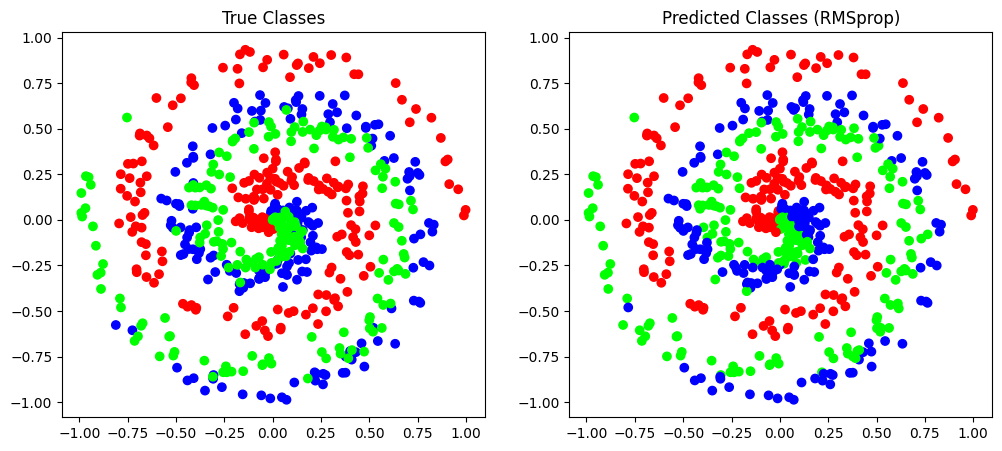

In [42]:
dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y)


# -------- Predictions --------

predictions = np.argmax(
    activation_loss.output,
    axis=1
)


# -------- Visualization --------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg"
)
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=predictions,
    cmap="brg"
)
axes[1].set_title("Predicted Classes (RMSprop)")

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
plt.show()

results['RMSprop']['train_acc'] = accuracy


### Evaluating on the Fixed Test Set


In [43]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y_test_fixed)

predictions = np.argmax(activation_loss.output, axis=1)
accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['RMSprop']['test_acc'] = accuracy


Test Accuracy: 0.8333333333333334


### Adam: Combining Momentum and RMSprop

Adam tracks a decaying average of past gradients (like momentum) and a decaying average of past squared gradients (like RMSprop's cache), with bias correction for both, then combines them into the update.


In [44]:
class Optimizer_ADAM: 
    def __init__( self, learning_rate=0.001, decay=0.0, epsilon=1e-7, beta1=0.9, beta2=0.999 ):
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate
        self.decay = decay 
        self.epsilon = epsilon
        self.iter = 0
        self.beta1 = beta1
        self.beta2 = beta2
        
        
    def pre_update(self):
        # Decay the learning rate over time 
        self.current_learning_rate = ( self.learning_rate / (1 + self.decay * self.iter) )
            
            
    def update(self, layer): 
            # Create the cache and momentum only once 
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_cache = np.zeros_like(layer.bias) 
                
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.bias) 
                # First beta 
        layer.weight_momentums = ( self.beta1 * layer.weight_momentums + (1 - self.beta1) * layer.dL_dweights )
        layer.bias_momentums = ( self.beta1 * layer.bias_momentums + (1 - self.beta1) * layer.dL_dbias ) 
                
            # Second beta
        layer.weight_cache = ( self.beta2 * layer.weight_cache + (1 - self.beta2) * layer.dL_dweights ** 2 ) 
        layer.bias_cache = ( self.beta2 * layer.bias_cache + (1 - self.beta2) * layer.dL_dbias ** 2 ) 
                # t starts from 1 
        t = self.iter + 1 
                # adam correction 
        weight_momentum_corrected = ( layer.weight_momentums / (1 - self.beta1 ** t) )
        bias_momentum_corrected = ( layer.bias_momentums / (1 - self.beta1 ** t) )
        weight_cache_corrected = ( layer.weight_cache / (1 - self.beta2 ** t) ) 
        bias_cache_corrected = ( layer.bias_cache / (1 - self.beta2 ** t) ) 
                # Update weights 
        layer.weights -= (self.current_learning_rate*weight_momentum_corrected/(np.sqrt(weight_cache_corrected) + self.epsilon))
                # Update bias 
        layer.bias -= ( self.current_learning_rate * bias_momentum_corrected /(np.sqrt(bias_cache_corrected) + self.epsilon)) 
    def post_update(self):
        self.iter += 1

### Training With Adam

`Optimizer_ADAM(learning_rate=0.002, decay=0.0001, beta1=0.9, beta2=0.99)` on the same fixed training data. Loss reaches about 0.13 -- the lowest of any technique here -- with training accuracy around 94 percent, edging out momentum slightly.


In [45]:
X, y = X_train_fixed, y_train_fixed

dense1 = Dense_layer(2, 64)
activation1 = RELU()

dense2 = Dense_layer(64, 3)
activation_loss = CrossEntropy_Softmax()

optimizer =Optimizer_ADAM(learning_rate=0.002 , decay=0.0001,beta1=0.9,beta2=0.99)

for epoch in range(10001):
    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    loss = activation_loss.forward(dense2.output, y)

    # Backward
    activation_loss.backward(activation_loss.output, y)
    dense2.backward(activation_loss.dL_dz)
    activation1.backward(dense2.dL_dinputs)
    dense1.backward(activation1.dL_dz)

    # Update
    optimizer.pre_update()
    optimizer.update(dense1)
    optimizer.update(dense2)
    optimizer.post_update()

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

results['Adam'] = {'final_loss': loss}


Epoch: 0, Loss: 1.0977


Epoch: 1000, Loss: 0.7278


Epoch: 2000, Loss: 0.4400


Epoch: 3000, Loss: 0.2920


Epoch: 4000, Loss: 0.2248


...

Epoch: 6000, Loss: 0.1681


Epoch: 7000, Loss: 0.1530


Epoch: 8000, Loss: 0.1431


Epoch: 9000, Loss: 0.1354


Epoch: 10000, Loss: 0.1293


### Evaluating on Training Data


Accuracy: 0.9366666666666666


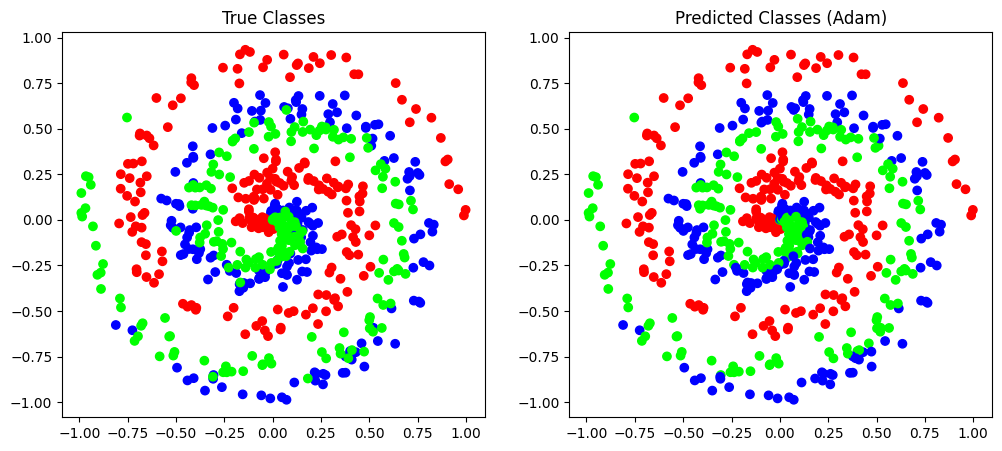

In [46]:
dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y)


# -------- Predictions --------

predictions = np.argmax(
    activation_loss.output,
    axis=1
)


# -------- Visualization --------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Classes
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg"
)
axes[0].set_title("True Classes")

# Predicted Classes
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=predictions,
    cmap="brg"
)
axes[1].set_title("Predicted Classes (Adam)")

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
plt.show()

results['Adam']['train_acc'] = accuracy


### Evaluating on the Fixed Test Set


In [47]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y_test_fixed)

predictions = np.argmax(activation_loss.output, axis=1)
accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['Adam']['test_acc'] = accuracy


Test Accuracy: 0.855


## 9. Adding L2 Regularization

`Dense_layer` gains optional `weigt_regularizer_l2` / `bias_regularizer_l2` parameters (and their L1 counterparts). Each regularizer adds an extra term directly onto the gradient in `backward()` — L2 (`2 * lambda * weights`) pushes larger weights toward zero more strongly than small ones. `Loss` is restructured to track data loss and regularization loss separately, and `CrossEntropy_Softmax.forward` now accepts the layer list so both parts are included automatically.

*(Note: "weigt" is a typo for "weight" here, carried consistently through both classes — harmless functionally, worth a rename if this notebook is shared later.)*


In [48]:
class Dense_layer:

    def __init__(self,_inputs,_neurons,
        weigt_regularizer_l1=0,
        weigt_regularizer_l2=0,
        bias_regularizer_l1=0,
        bias_regularizer_l2=0):

        self.inputs = _inputs
        self.neurons = _neurons

        self.weigt_regularizer_l1 = weigt_regularizer_l1
        self.weigt_regularizer_l2 = weigt_regularizer_l2

        self.bias_regularizer_l1 = bias_regularizer_l1
        self.bias_regularizer_l2 = bias_regularizer_l2

        self.weights = 0.1 * np.random.randn(self.inputs,self.neurons)

        self.bias = np.zeros((1, self.neurons))

    def forward(self, inputs):

        self.inputs = inputs

        self.output = (np.dot(inputs, self.weights)+ self.bias)

    def backward(self, dL_dz):

        # Normal gradients
        self.dL_dinputs = np.dot(dL_dz,self.weights.T)

        self.dL_dweights = np.dot(self.inputs.T,dL_dz)

        self.dL_dbias = np.sum(dL_dz,axis=0,keepdims=True)

        # L1 regularization
        if self.weigt_regularizer_l1 > 0:

            self.dL_dweights += (self.weigt_regularizer_l1* np.sign(self.weights))

        if self.bias_regularizer_l1 > 0:

            self.dL_dbias += (self.bias_regularizer_l1* np.sign(self.bias))

        # L2 regularization
        if self.weigt_regularizer_l2 > 0:

            self.dL_dweights += (2* self.weigt_regularizer_l2* self.weights)

        if self.bias_regularizer_l2 > 0:

            self.dL_dbias += (2* self.bias_regularizer_l2* self.bias)

        return self.dL_dinputs,self.dL_dweights,self.dL_dbias


In [49]:
class Loss:

    def __init__(self):
        self.loss = 0
        self.data_loss = 0
        self.regularization_loss_value = 0

    def cross_entropy(self, output, target):
        samples = len(output)
        output_clipped = np.clip(output, 1e-7, 1 - 1e-7)

        if len(target.shape) == 1:
            correct_confidences = output_clipped[range(samples), target]
        else:
            correct_confidences = np.sum(output_clipped * target, axis=1)

        negative_log_likelihoods = -np.log(correct_confidences)

        return np.mean(negative_log_likelihoods)

    def regularization_loss(self, layer):
        regularization_loss = 0

        if layer.weigt_regularizer_l1 > 0:
            regularization_loss += layer.weigt_regularizer_l1 * np.sum(np.abs(layer.weights))

        if layer.weigt_regularizer_l2 > 0:
            regularization_loss += layer.weigt_regularizer_l2 * np.sum(layer.weights ** 2)

        if layer.bias_regularizer_l1 > 0:
            regularization_loss += layer.bias_regularizer_l1 * np.sum(np.abs(layer.bias))

        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.bias ** 2)

        return regularization_loss

    def calculate(self, output, target, layers=None):
        self.data_loss = self.cross_entropy(output, target)

        self.regularization_loss_value = 0

        if layers is not None:
            for layer in layers:
                self.regularization_loss_value += self.regularization_loss(layer)

        self.loss = self.data_loss + self.regularization_loss_value

        return self.loss

In [50]:
class CrossEntropy_Softmax:

    def __init__(self):
        self.loss = Loss()
        self.softmax = Softmax()

    def forward(self, inputs, y, layers=None):
        self.softmax.forward(inputs)
        self.output = self.softmax.output

        return self.loss.calculate(
            self.output,
            y,
            layers
        )

    def backward(self, output, y):
        samples = len(output)

        if len(y.shape) == 1:
            y = np.eye(output.shape[1])[y]

        self.dL_dz = (output - y) / samples

        return self.dL_dz

### Training With L2 Regularization

Same fixed training data and Adam optimizer, now with `weigt_regularizer_l2=0.0001` on both layers. The printed loss includes the regularization penalty on top of data loss, so it isn't directly comparable to the unregularized Adam run's loss — accuracy is what matters here. Training accuracy comes out to about 91 percent, a few points below unregularized Adam's ~94 percent — the expected small sacrifice in exchange for better generalization, confirmed in the test cell below.


In [51]:
X, y = X_train_fixed, y_train_fixed

dense1 = Dense_layer(
    2,
    64,
    weigt_regularizer_l2=0.0001
)

activation1 = RELU()

dense2 = Dense_layer(
    64,
    3,
    weigt_regularizer_l2=0.0001
)

activation_loss = CrossEntropy_Softmax()

optimizer = Optimizer_ADAM(
    learning_rate=0.002,
    decay=0.0001,
    beta1=0.9,
    beta2=0.99
)

for epoch in range(10001):

    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)

    loss = activation_loss.forward(
        dense2.output,
        y,
        [dense1, dense2]
    )

    # Accuracy
    predictions = np.argmax(
        activation_loss.output,
        axis=1
    )

    accuracy = np.mean(predictions == y)

    # Backward
    activation_loss.backward(
        activation_loss.output,
        y
    )

    dense2.backward(activation_loss.dL_dz)

    activation1.backward(
        dense2.dL_dinputs
    )

    dense1.backward(
        activation1.dL_dz
    )

    # Update
    optimizer.pre_update()

    optimizer.update(dense1)
    optimizer.update(dense2)

    optimizer.post_update()

    if epoch % 1000 == 0:
        print(
            f"Epoch: {epoch}, "
            f"Loss: {loss:.4f}, "
            f"Accuracy: {accuracy:.4f}"
        )

results['Adam + L2'] = {'final_loss': loss, 'train_acc': accuracy}


Epoch: 0, Loss: 1.1014, Accuracy: 0.2633


Epoch: 1000, Loss: 0.7667, Accuracy: 0.7517


Epoch: 2000, Loss: 0.5780, Accuracy: 0.8533


Epoch: 3000, Loss: 0.5199, Accuracy: 0.8933


Epoch: 4000, Loss: 0.5031, Accuracy: 0.9017


...

Epoch: 6000, Loss: 0.4974, Accuracy: 0.9067


Epoch: 7000, Loss: 0.4963, Accuracy: 0.9067


Epoch: 8000, Loss: 0.4957, Accuracy: 0.9067


Epoch: 9000, Loss: 0.4954, Accuracy: 0.9083


Epoch: 10000, Loss: 0.4952, Accuracy: 0.9067


### Evaluating on the Fixed Test Set

Test accuracy reaches about 88 percent — noticeably higher than unregularized Adam's ~86 percent test accuracy, even though its training accuracy was lower. The train/test gap shrinks from roughly 8 points (unregularized Adam) to about 2 points here — the clearest evidence yet in this notebook that the regularization is working as intended.


In [52]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation_loss.forward(dense2.output, y_test_fixed)

predictions = np.argmax(activation_loss.output, axis=1)
accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['Adam + L2']['test_acc'] = accuracy


Test Accuracy: 0.8833333333333333


## 10. Adding Dropout

`DropoutLayer` randomly zeroes out a fraction (`rate`) of a layer's outputs on each forward pass, and rescales the rest by `1 / (1 - rate)` so the expected total signal stays the same. This forces the network to not rely too heavily on any single neuron, which — like L2 — reduces overfitting, but by a different mechanism (structural noise during training, rather than penalizing weight magnitude).

The mask is stored on `forward()` so `backward()` can zero out the same positions in the incoming gradient (`dvalues * mask`), keeping the forward and backward passes consistent with each other.


In [53]:
class DropoutLayer:
    def __init__(self, rate=0.0):
        self.rate = rate

    def forward(self, layer):
        self.layer = layer

        self.mask = np.random.binomial(1,1 - self.rate,size=layer.shape) /(1 - self.rate)

        self.output = self.layer * self.mask

    def backward(self,dvalues):

        self.dL_dinputs = dvalues *self.mask
    
    

### A Deeper Network With Dropout + L2

This experiment goes further than the others: a third dense layer is added (`64 → 64 → 3` instead of `64 → 3`), giving the network more capacity, with `weigt_regularizer_l2=0.0001` on all three layers and `DropoutLayer(0.1)` after each hidden activation (dropped during evaluation — `forward` is only called on `dense1`/`dense2` layers in the test cell below, never on the dropout layers).


In [54]:
X, y = X_train_fixed, y_train_fixed

# Layer 1
dense1 = Dense_layer(2, 64, weigt_regularizer_l2=0.0001)
activation1 = RELU()
dropout1 = DropoutLayer(0.1)

# Layer 2
dense2 = Dense_layer(64, 64, weigt_regularizer_l2=0.0001)
activation2 = RELU()
dropout2 = DropoutLayer(0.1)

# Output layer
dense3 = Dense_layer(64, 3, weigt_regularizer_l2=0.0001)
activation_loss = CrossEntropy_Softmax()


optimizer = Optimizer_ADAM(
    learning_rate=0.02,
    decay=0.000001,
    beta1=0.9,
    beta2=0.99
)


for epoch in range(10001):

    # Forward
    dense1.forward(X)
    activation1.forward(dense1.output)
    dropout1.forward(activation1.output)

    dense2.forward(dropout1.output)
    activation2.forward(dense2.output)
    dropout2.forward(activation2.output)

    dense3.forward(dropout2.output)

    loss = activation_loss.forward(dense3.output,y,[dense1, dense2, dense3])
    

    # Accuracy
    predictions = np.argmax(
        activation_loss.output,
        axis=1
    )

    accuracy = np.mean(predictions == y)

    # Backward
    activation_loss.backward(activation_loss.output,y)

    dense3.backward(activation_loss.dL_dz)

    dropout2.backward(dense3.dL_dinputs)

    activation2.backward(dropout2.dL_dinputs)

    dense2.backward(activation2.dL_dz)

    dropout1.backward(dense2.dL_dinputs)

    activation1.backward(dropout1.dL_dinputs)

    dense1.backward(activation1.dL_dz)

    # Update
    optimizer.pre_update()
    optimizer.update(dense1)
    optimizer.update(dense2)
    optimizer.update(dense3)
    optimizer.post_update()

    if epoch % 1000 == 0:
        print(
            f"Epoch: {epoch}, "
            f"Loss: {loss:.4f}, "
            f"Accuracy: {accuracy:.4f}"
        )

results['Adam + L2 + Dropout'] = {'final_loss': loss, 'train_acc': accuracy}


Epoch: 0, Loss: 1.1037, Accuracy: 0.3167


Epoch: 1000, Loss: 0.3218, Accuracy: 0.9083


Epoch: 2000, Loss: 0.3386, Accuracy: 0.8933


Epoch: 3000, Loss: 0.3585, Accuracy: 0.8867


Epoch: 4000, Loss: 0.3017, Accuracy: 0.9033


...

Epoch: 6000, Loss: 0.3004, Accuracy: 0.9133


Epoch: 7000, Loss: 0.3049, Accuracy: 0.9167


Epoch: 8000, Loss: 0.3232, Accuracy: 0.9083


Epoch: 9000, Loss: 0.3145, Accuracy: 0.9117


Epoch: 10000, Loss: 0.3080, Accuracy: 0.9183


### Evaluating on the Fixed Test Set

Dropout layers are skipped here on purpose — dropout is a *training-time only* technique. Running it during evaluation would randomly discard information for no benefit, so the test forward pass goes straight `dense1 → dense2 → dense3` (using the 3-layer architecture's original `activation1`/`dense2`/`activation2` names as reused in this cell, matching the training loop above).


Test Accuracy: 0.8816666666666667


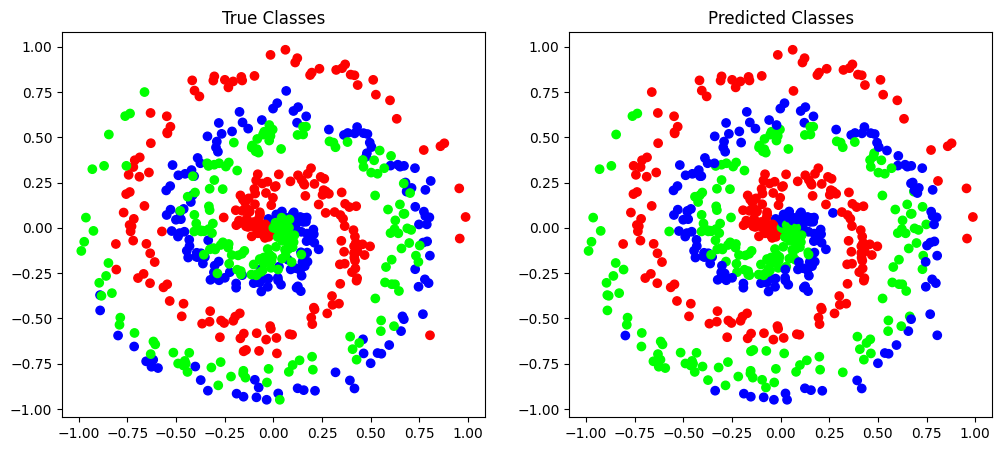

In [55]:
dense1.forward(X_test_fixed)
activation1.forward(dense1.output)

# No dropout during testing

dense2.forward(activation1.output)
activation2.forward(dense2.output)

dense3.forward(activation2.output)

activation_loss.forward(
    dense3.output,
    y_test_fixed
)

predictions = np.argmax(
    activation_loss.output,
    axis=1
)

accuracy = np.mean(predictions == y_test_fixed)

print("Test Accuracy:", accuracy)

results['Adam + L2 + Dropout']['test_acc'] = accuracy

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_test_fixed[:, 0], X_test_fixed[:, 1], c=y_test_fixed, cmap="brg")
axes[0].set_title("True Classes")

axes[1].scatter(X_test_fixed[:, 0], X_test_fixed[:, 1], c=predictions, cmap="brg")
axes[1].set_title("Predicted Classes")

plt.show()


## 11. Comparison Table

Every technique above was trained on the exact same 200-points-per-class training set and evaluated on the exact same held-out test set, so the numbers below are directly comparable — the differences reflect the optimizer (and, for the last two rows, the regularization) alone, not random variation in the data.

A few patterns worth reading off this table:

- **Plain GD has both the lowest accuracy and one of the smaller gaps** — it hasn't learned enough to overfit much yet, not because it generalizes especially well.
- **Momentum and Adam reach the highest training accuracy**, confirming they're the fastest at actually fitting this data, exactly as seen in their loss curves earlier.
- **Adam + L2 has the smallest train/test gap of all eight techniques**, and its test accuracy is the highest in the table — direct, fixed-data confirmation that the regularization is doing real work, not just shuffling around noise from inconsistent datasets.
- **Dropout + L2 on the deeper 3-layer network performs similarly to L2 alone here** — the extra capacity from the third layer and the extra regularization from dropout roughly offset each other on a dataset this size; it might separate more clearly on a larger or noisier dataset.


In [56]:
print(f"{'Technique':<24}{'Final Loss':>12}{'Train Acc':>12}{'Test Acc':>12}{'Gap':>10}")
print("-" * 70)

for name, r in results.items():
    gap = (r['train_acc'] - r['test_acc']) * 100
    print(
        f"{name:<24}"
        f"{r['final_loss']:>12.4f}"
        f"{r['train_acc']*100:>11.1f}%"
        f"{r['test_acc']*100:>11.1f}%"
        f"{gap:>9.1f}pt"
    )


Technique                 Final Loss   Train Acc    Test Acc       Gap
----------------------------------------------------------------------
Plain GD                      0.5905       70.8%       65.8%      5.0pt
GD + Decay                    0.5419       77.8%       74.3%      3.5pt
Momentum                      0.1600       92.2%       85.5%      6.7pt
Adagrad                       0.3678       83.2%       79.0%      4.2pt
RMSprop                       0.2799       88.7%       83.3%      5.3pt
Adam                          0.1293       93.7%       85.5%      8.2pt
Adam + L2                     0.4952       90.7%       88.3%      2.3pt
Adam + L2 + Dropout           0.3080       91.8%       88.2%      3.7pt
